In [1]:
import scanpy as sc 
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.metrics import adjusted_rand_score
from sklearn.decomposition import PCA

import scipy.sparse as sp 
import warnings
import torch

warnings.filterwarnings("ignore")

import os
import ctypes
import sys

# 1. 先设置 R_HOME
os.environ["R_HOME"] = "/home/pxy/miniconda3/envs/r40/lib/R"

# 2. 【核心黑科技】手动加载 R 的动态库
# 这步操作等同于在终端里设置 LD_LIBRARY_PATH，专门解决 VS Code 找不到库的问题
try:
    # 这是 R 的核心库路径
    libR_path = "/home/pxy/miniconda3/envs/r40/lib/R/lib/libR.so"
    # 强制加载进内存
    ctypes.CDLL(libR_path, mode=ctypes.RTLD_GLOBAL)
    print("✅ 成功强制加载 libR.so")
except OSError as e:
    print(f"❌ 加载失败: {e}")

# 3. 然后再导入其他包
sys.path.append("..") 

import models
import rpy2.robjects as robjects
print("R 环境路径:", robjects.r['R.home']()[0])

models.fix_seed(0)

✅ 成功强制加载 libR.so
R 环境路径: /home/pxy/miniconda3/envs/r40/lib/R


In [2]:
import scanpy as sc 
import os
import warnings
warnings.filterwarnings("ignore")

# ====================== 配置 ======================
data_dir = '/home/pxy/home/pxy/data/Mouse_Visual_Cortex/'
sample_name = "STARmap_20180505_BY3_1k"

# ====================== 只需要读 h5ad 就够了！ ======================
adata = sc.read_h5ad(os.path.join(data_dir, f"{sample_name}.h5ad"))
adata.var_names_make_unique()

# ====================== 空间坐标 ======================
adata.obsm["spatial"] = adata.obs[["X", "Y"]].values

# ====================== 直接用 label 作为 GroundTruth ======================
# 把 label 重命名成 Region，和 DLPFC 格式一致
adata.obs["Region"] = adata.obs["label"].astype("category")

# ====================== 验证 ======================
print(adata)
print("\n✅ Ground Truth (label) 分布：")
print(adata.obs["Region"].value_counts())
print("NA 数量：", adata.obs["Region"].isna().sum())

AnnData object with n_obs × n_vars = 1207 × 1020
    obs: 'Total_counts', 'X', 'Y', 'label', 'Region'
    uns: 'label_colors'
    obsm: 'spatial'

✅ Ground Truth (label) 分布：
Region
L2/3    262
L4      230
L6      223
L5      156
CC      154
L1      113
HPC      69
Name: count, dtype: int64
NA 数量： 0


In [3]:
n_clusters = adata.obs["Region"].nunique()
print(f"\n✅ 共有 {n_clusters} 个 Region (原始 label)")


✅ 共有 7 个 Region (原始 label)


In [4]:
adata = models.preprocess(adata)
adata.obsm["X_pca"] = PCA(n_components=200, random_state=0).fit_transform(adata.X)
g_spatia = models.prepare_graph(adata, "spatial",n_neighbors=6)
g_expr = models.prepare_graph(adata, "expr", metric="euclidean",n_neighbors=4)
graph_dict = {"spatial": g_spatia, "expr":g_expr}

normalized data ---------------->
正在构建图: spatial, 使用度量: cosine ...
  -> 使用空间坐标 (euclidean)
  -> 计算最近邻 (NearestNeighbors)...
  -> 对称化与归一化...
spatial graph created successfully <----

正在构建图: expr, 使用度量: euclidean ...
  -> 使用 PCA 降维特征 
  -> 计算最近邻 (NearestNeighbors)...
  -> 对称化与归一化...
expr graph created successfully <----



In [5]:
model = models.model_TwoStage(
    adata.obsm["X_pca"], 
    graph_dict, 
    n_clusters=n_clusters,
    dim_input=200,
    pretrain_epochs=100,   # 预训练200轮
    finetune_epochs=100,   # 训练300轮
    gamma=0.1,             # 重构损失权重
    beta=0.0,              # 聚类损失权重=0 
    kappa=2.0,             # 对比损失权重
    theta=0.1,             # 平滑项损失权重
    dim_hidden=64,
    freeze_encoder=False,   # 冻结预训练编码器
    graph_corr=0.0,
    dropout=0.1,
    gate_bias=4.0,
    residual_weight=0.5
)

In [6]:
pred, embed, gated_weights = model.train()

Stage 1: Pre-training Shared Encoder


Pretrain:  18%|█▊        | 18/100 [00:01<00:05, 15.42it/s]

  Pretrain Epoch 10: Rec Loss = 2.653661
  Pretrain Epoch 20: Rec Loss = 2.589805


Pretrain:  44%|████▍     | 44/100 [00:02<00:01, 42.85it/s]

  Pretrain Epoch 30: Rec Loss = 2.549770
  Pretrain Epoch 40: Rec Loss = 2.521880


...

  Train Epoch 80: Loss = 14.242886,Rec Loss = 2.652475, Contrast Loss = 6.975053, Smooth Loss = 0.275328


Finetune:  92%|█████████▏| 92/100 [00:07<00:00, 11.75it/s]

  Train Epoch 90: Loss = 14.229711,Rec Loss = 2.653477, Contrast Loss = 6.969279, Smooth Loss = 0.258042


Finetune: 100%|██████████| 100/100 [00:08<00:00, 12.06it/s]


  Train Epoch 100: Loss = 14.216050,Rec Loss = 2.654886, Contrast Loss = 6.963197, Smooth Loss = 0.241681

  Finetune Epoch 100:
    Total Loss   = 14.2161
    Rec Loss     = 2.6549
    Contrast Loss = 6.9632
    Smooth Loss = 0.2417

✓ Finetune finished (max epochs reached)


In [7]:
# ========== 聚类 ==========
adata.obsm["model_twostage"] = embed
models.clustering(adata, n_clusters, key="model_twostage", refinement=True, cluster_methods='kmeans')

AnnData object with n_obs × n_vars = 1207 × 1020
    obs: 'Total_counts', 'X', 'Y', 'label', 'Region', 'n_counts', 'kmeans', 'kmeans_refined'
    var: 'n_counts', 'mean', 'std'
    uns: 'label_colors', 'log1p'
    obsm: 'spatial', 'X_pca', 'model_twostage'
    layers: 'count'

In [8]:
print(f"Original KMeans unique labels: {len(np.unique(adata.obs['kmeans_refined']))}")

Original KMeans unique labels: 7


In [9]:
# ========== 评估 ==========
adata_filtered = adata[adata.obs.Region.notna()]
ARI_kmeans = adjusted_rand_score(adata_filtered.obs["Region"], 
                        adata_filtered.obs["kmeans_refined"])
print(f"\nFinal Kmeans ARI on {sample_name}: {ARI_kmeans:.8f}")


Final Kmeans ARI on STARmap_20180505_BY3_1k: 0.67592683


In [10]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score
mask = adata.obs.Region.notna()
X = embed[mask]
labels = adata.obs["kmeans_refined"][mask]

# 1. 计算 SC 指数
# 注意：样本量巨大时（如 >10万点），silhouette_score 会非常慢，建议下采样
sc_val = silhouette_score(X, labels)

# 2. 计算 CH 指数
ch_val = calinski_harabasz_score(X, labels)

print(f"Internal Evaluation for {sample_name}:")
print(f"Silhouette Coefficient (SC): {sc_val:.4f}")
print(f"Calinski-Harabasz Index (CH): {ch_val:.4f}")

Internal Evaluation for STARmap_20180505_BY3_1k:
Silhouette Coefficient (SC): 0.3203
Calinski-Harabasz Index (CH): 438.4940


In [11]:
from sklearn.metrics import normalized_mutual_info_score

# ========== 评估 ==========
adata_filtered = adata[adata.obs.Region.notna()]

# 2. 计算 NMI (新增代码)
NMI_kmeans = normalized_mutual_info_score(adata_filtered.obs["Region"], 
                                          adata_filtered.obs["kmeans_refined"])

print(f"\nFinal Results on {sample_name}:")
print(f"ARI: {ARI_kmeans:.4f}")
print(f"NMI: {NMI_kmeans:.4f}")


Final Results on STARmap_20180505_BY3_1k:
ARI: 0.6759
NMI: 0.7459


In [12]:
from sklearn.metrics import adjusted_mutual_info_score, fowlkes_mallows_score

ami = adjusted_mutual_info_score(adata_filtered.obs["Region"], adata_filtered.obs["kmeans_refined"])
fmi = fowlkes_mallows_score(adata_filtered.obs["Region"], adata_filtered.obs["kmeans_refined"])
print(f"Adjusted Mutual Information (AMI): {ami:.4f}")
print(f"Fowlkes-Mallows Index (FMI): {fmi:.4f}")

Adjusted Mutual Information (AMI): 0.7438
Fowlkes-Mallows Index (FMI): 0.7317


In [ ]:
# adata.obs["model"] = adata.obs["kmeans_refined"]
# sc.pl.spatial(adata, color=["Region", "model"],spot_size=40,      
#     frameon=False, 
#     show=True,  title=["Manual Annotation", f"Ours (ARI={round(ARI_kmeans, 2)})"])

In [13]:
figures_dir = "./figures_MVC_Starmap_best"
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir)

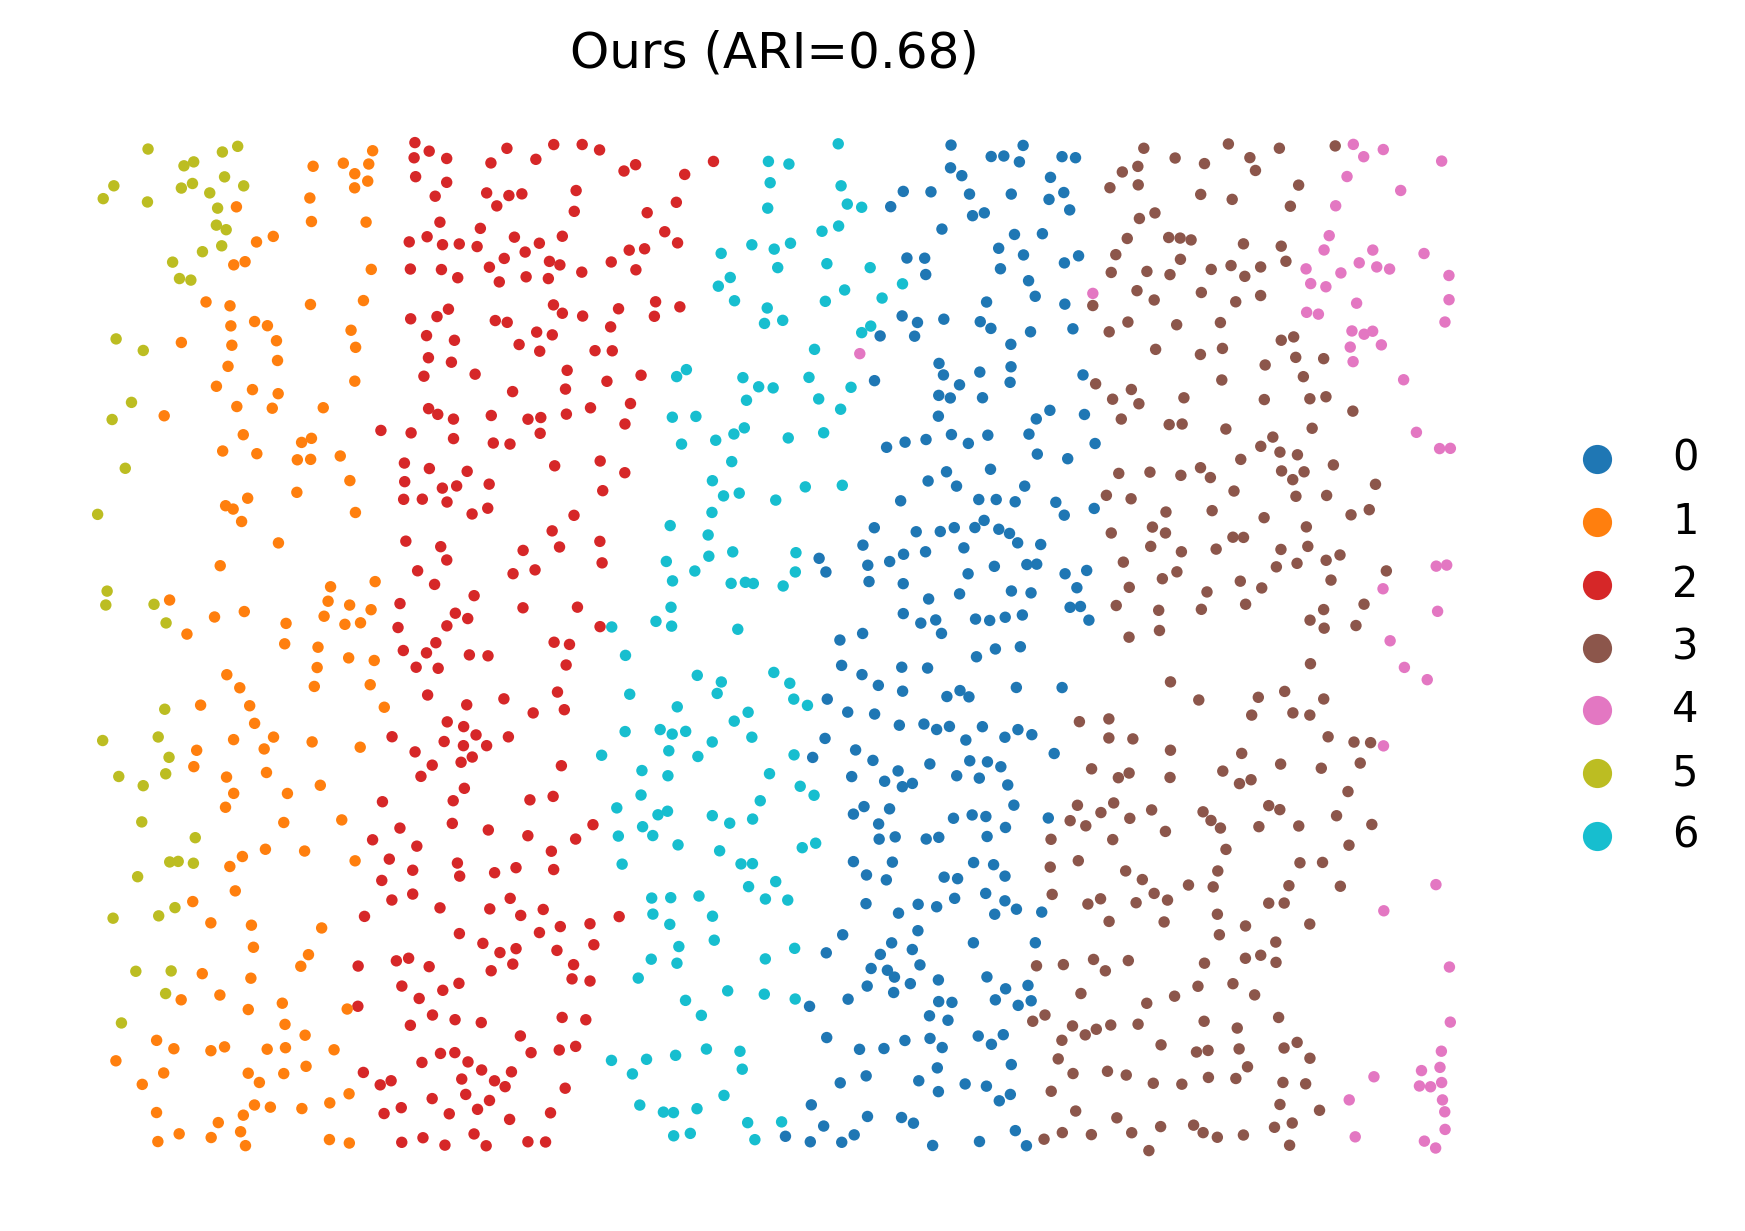

In [15]:
import scanpy as sc
import matplotlib.pyplot as plt

# 1. 先设置全局高对比度配色
plt.rcParams['figure.dpi'] = 300  # 高清分辨率
# plt.rcParams['figure.figsize'] = (8, 4)  # 加宽画布，让点更舒展
adata.obs["model"] = adata.obs["kmeans_refined"]
# 2. 复刻 STAGATE 风格的 mclust 图
sc.pl.embedding(
    adata,
    basis="spatial",
    color="model",
    s=30,  # 稍大一点，更清晰
    show=False,
    alpha=1.0,
    edgecolor="none",  # 关键：去掉描边，颜色更实
    palette="tab10",   # STAGATE 同款高饱和配色
    frameon=False,
    title=f"Ours (ARI={round(ARI_kmeans, 2)})"
)
for ext in ['png', 'svg', 'pdf']:
    plt.savefig(f"{figures_dir}/{sample_name}_spatial.{ext}", bbox_inches='tight', dpi=300 if ext=='png' else None)
plt.show()
plt.close()



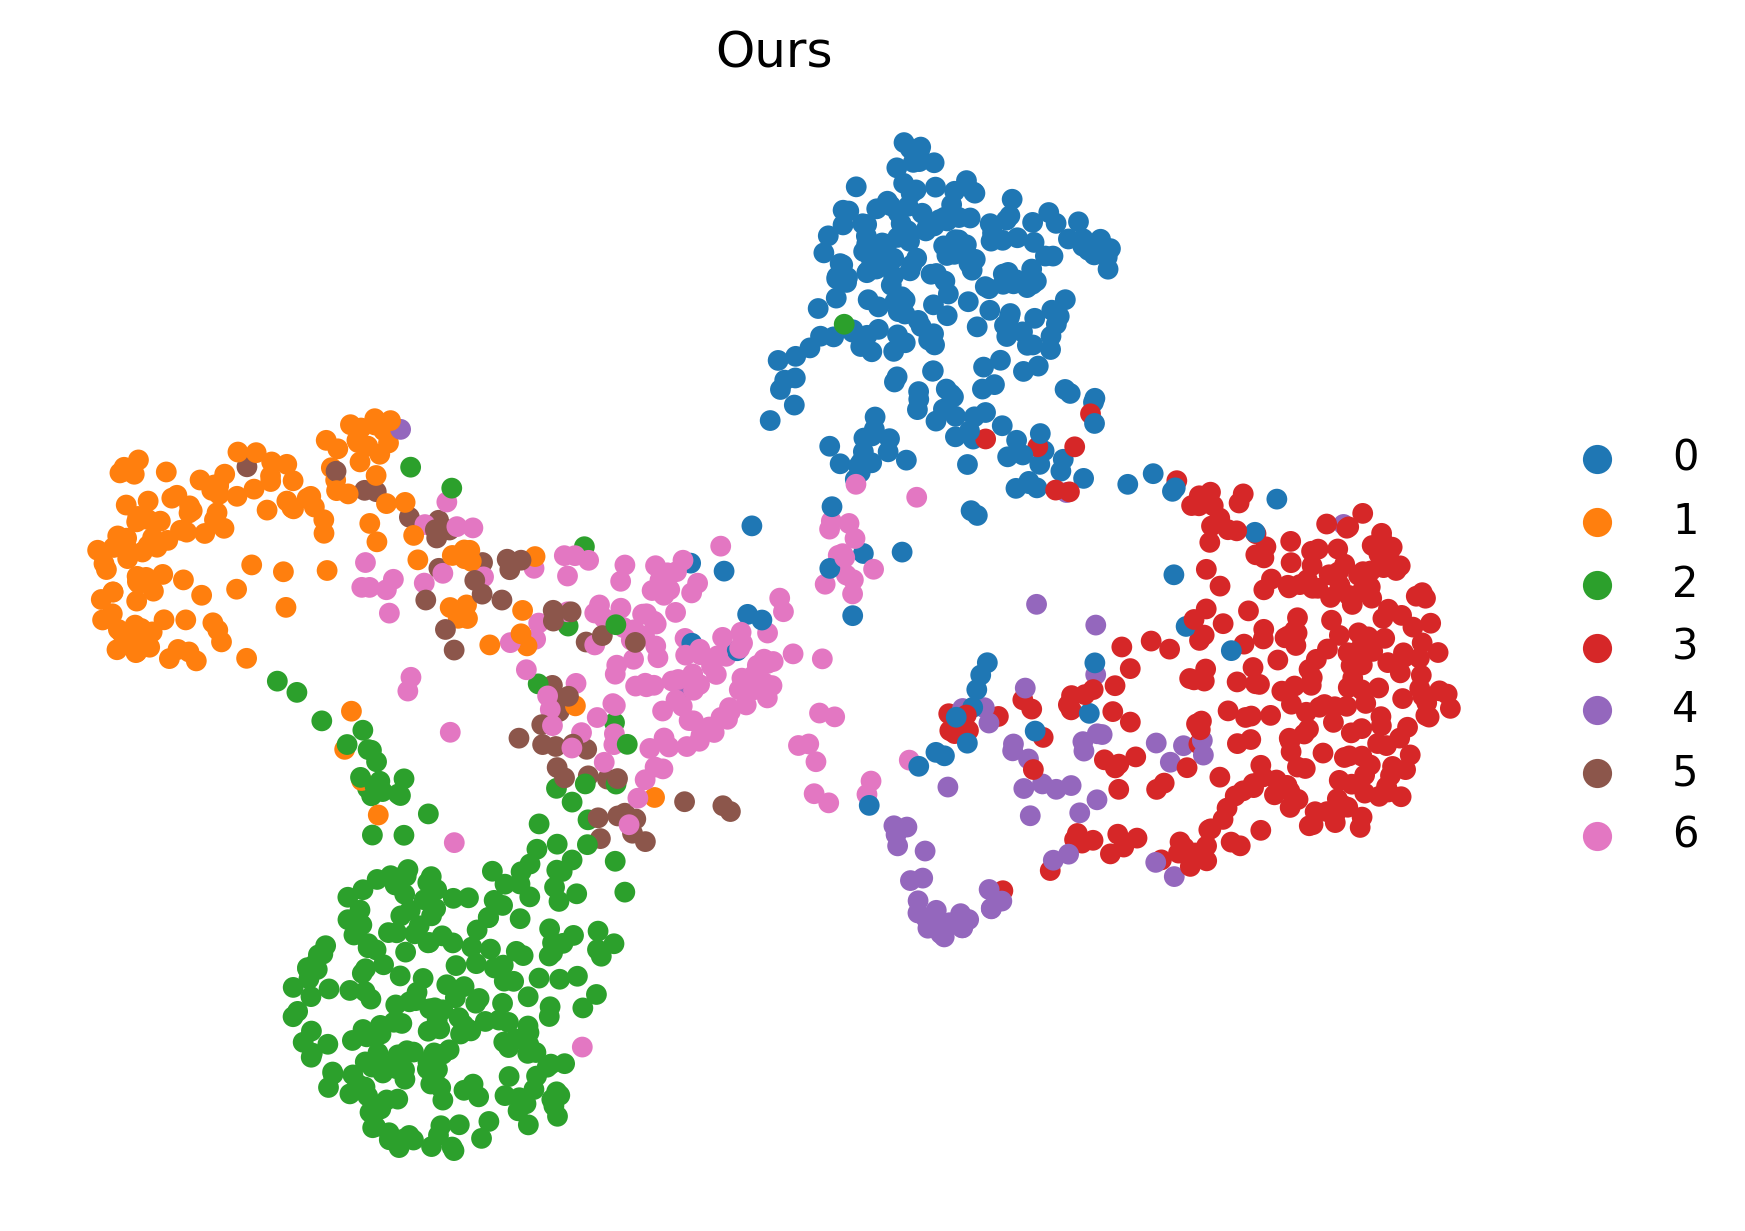

In [16]:
# 计算 UMAP
adata.obsm["embed"] = embed
sc.pp.neighbors(adata, n_neighbors=15, use_rep="embed")
sc.tl.umap(adata)
sc.pl.umap(adata, color=["kmeans_refined"], 
           title=["Ours"],
            frameon=False,      
           show=False) 


plt.savefig(f"{figures_dir}/{sample_name}_umap_without_frame.png", bbox_inches='tight')

for ext in ['png', 'svg', 'pdf']:
    plt.savefig(f"{figures_dir}/{sample_name}_umap_without_frame.{ext}", bbox_inches='tight', dpi=300 if ext=='png' else None)
plt.show()
plt.close()

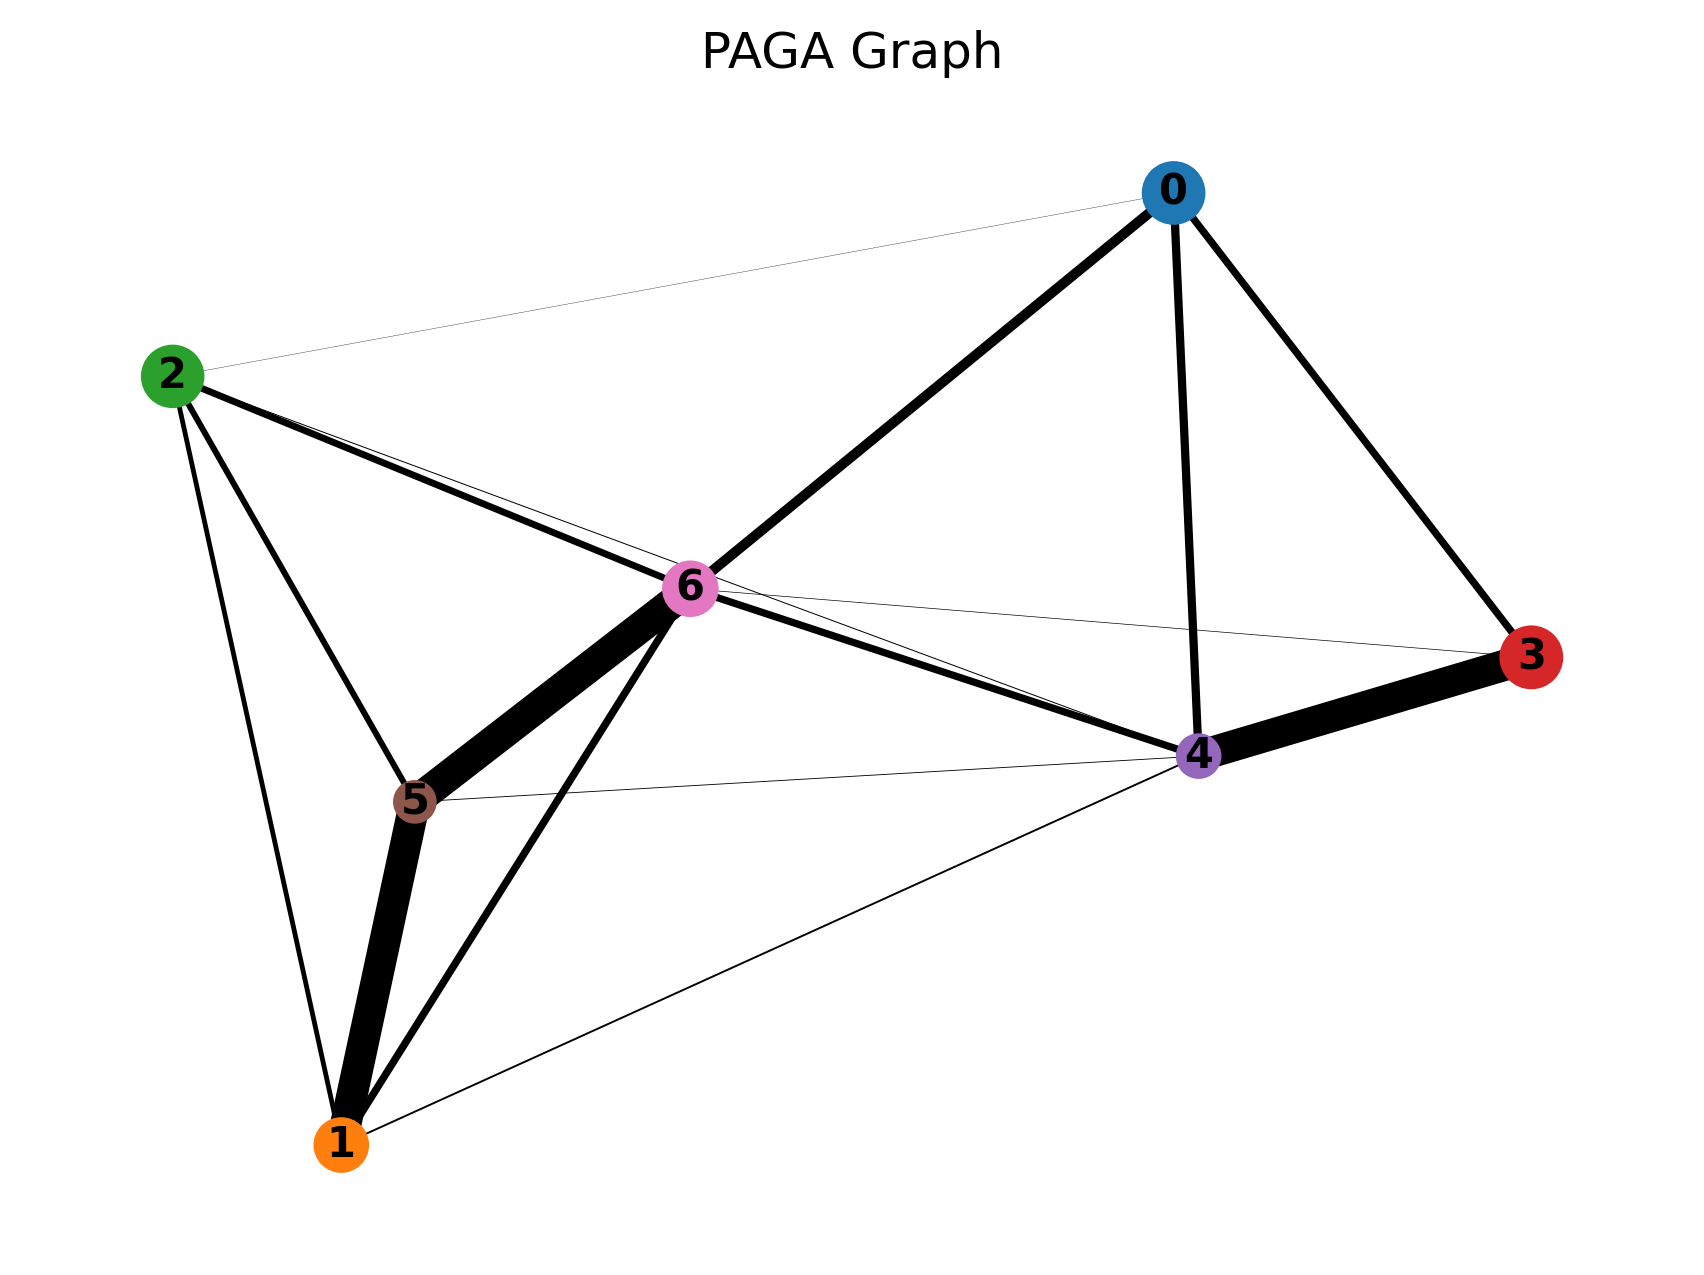

In [17]:

sc.tl.paga(adata, groups="kmeans_refined")


sc.pl.paga(adata, color="kmeans_refined", 
           title=f"PAGA Graph",
           frameon=False,
           show=False)


for ext in ['png', 'svg', 'pdf']:
    plt.savefig(f"{figures_dir}/{sample_name}_paga.{ext}", bbox_inches='tight', dpi=300 if ext=='png' else None)
plt.show()
plt.close()

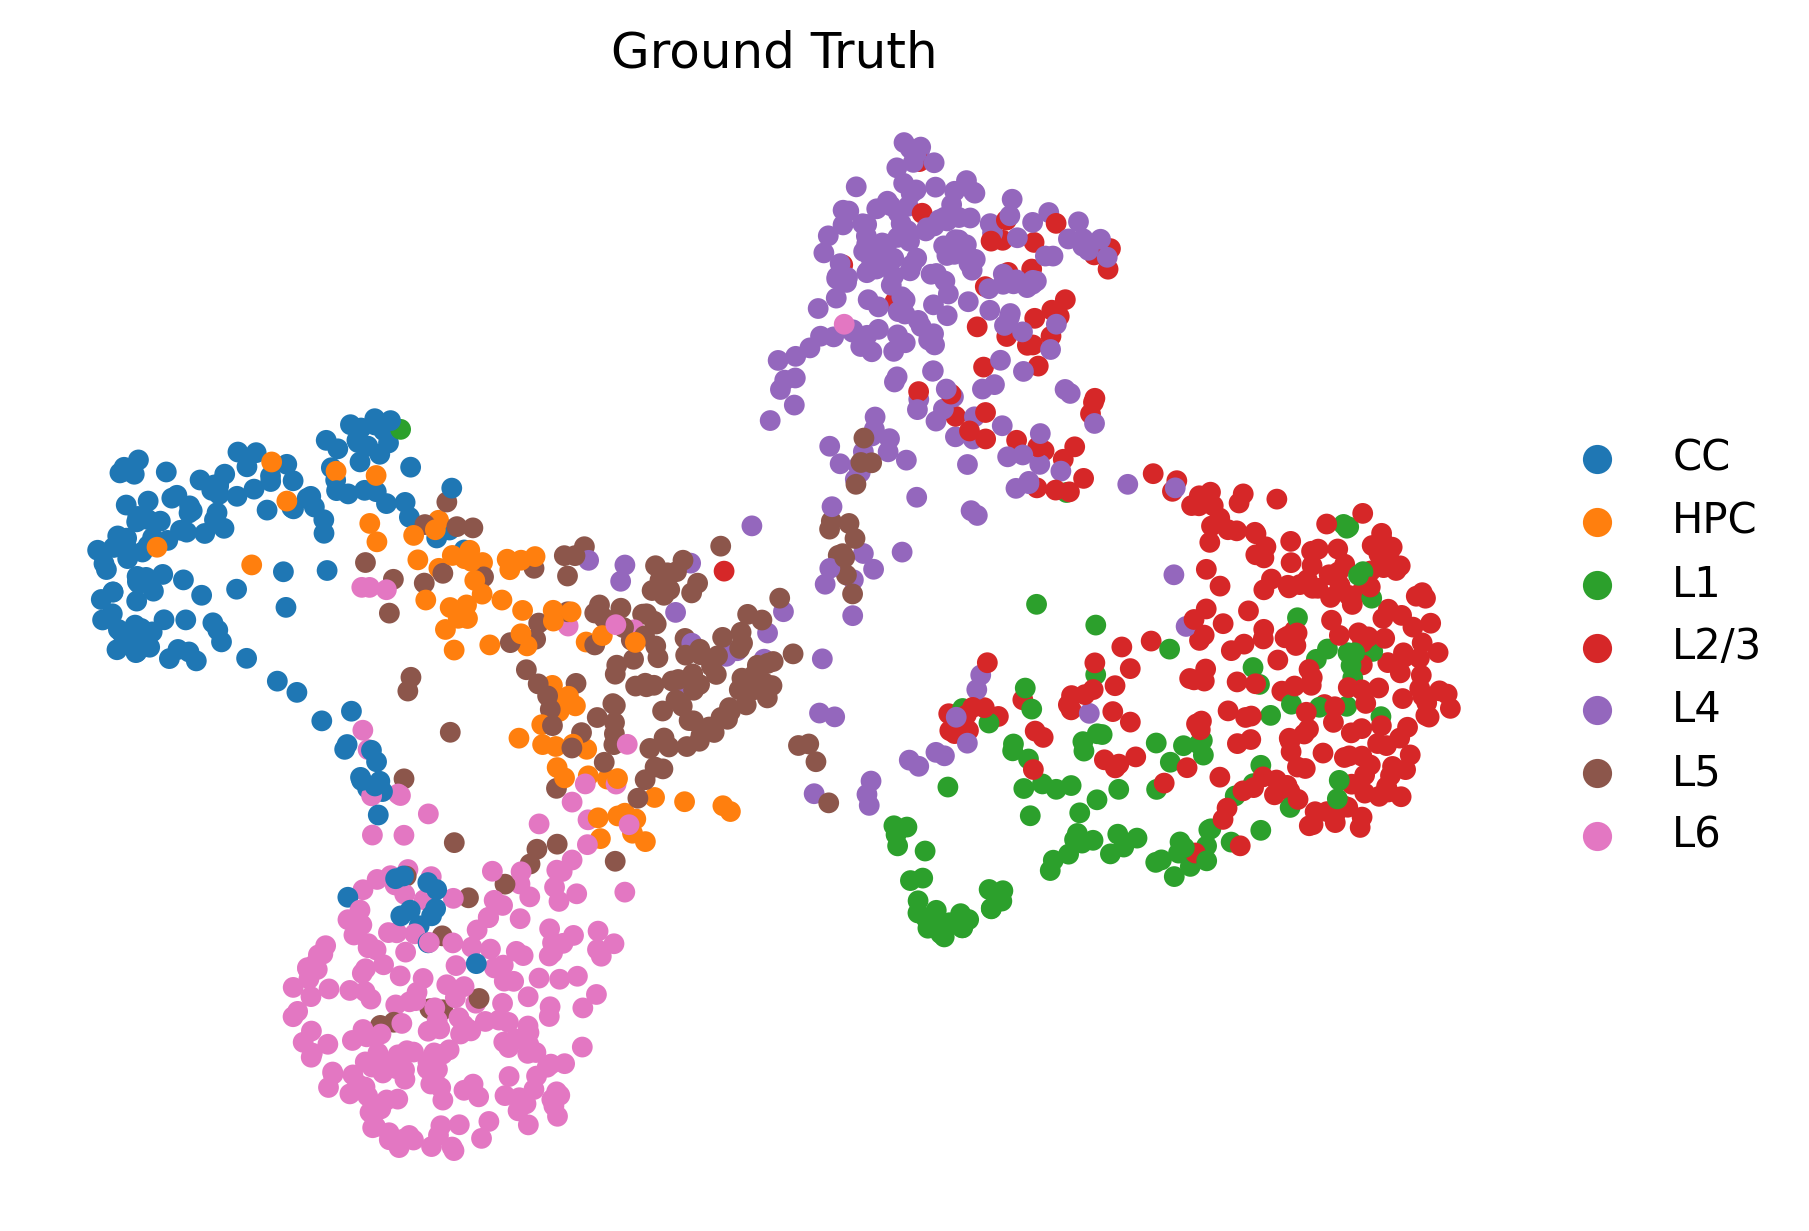

In [18]:
sc.pl.umap(adata, 
           color=["Region"], 
           title=["Ground Truth"],
           frameon=False,       
           show=False) 



for ext in ['png', 'svg', 'pdf']:
    plt.savefig(f"{figures_dir}/{sample_name}_umap_gt.{ext}", bbox_inches='tight', dpi=300 if ext=='png' else None)

plt.show() 
plt.close()

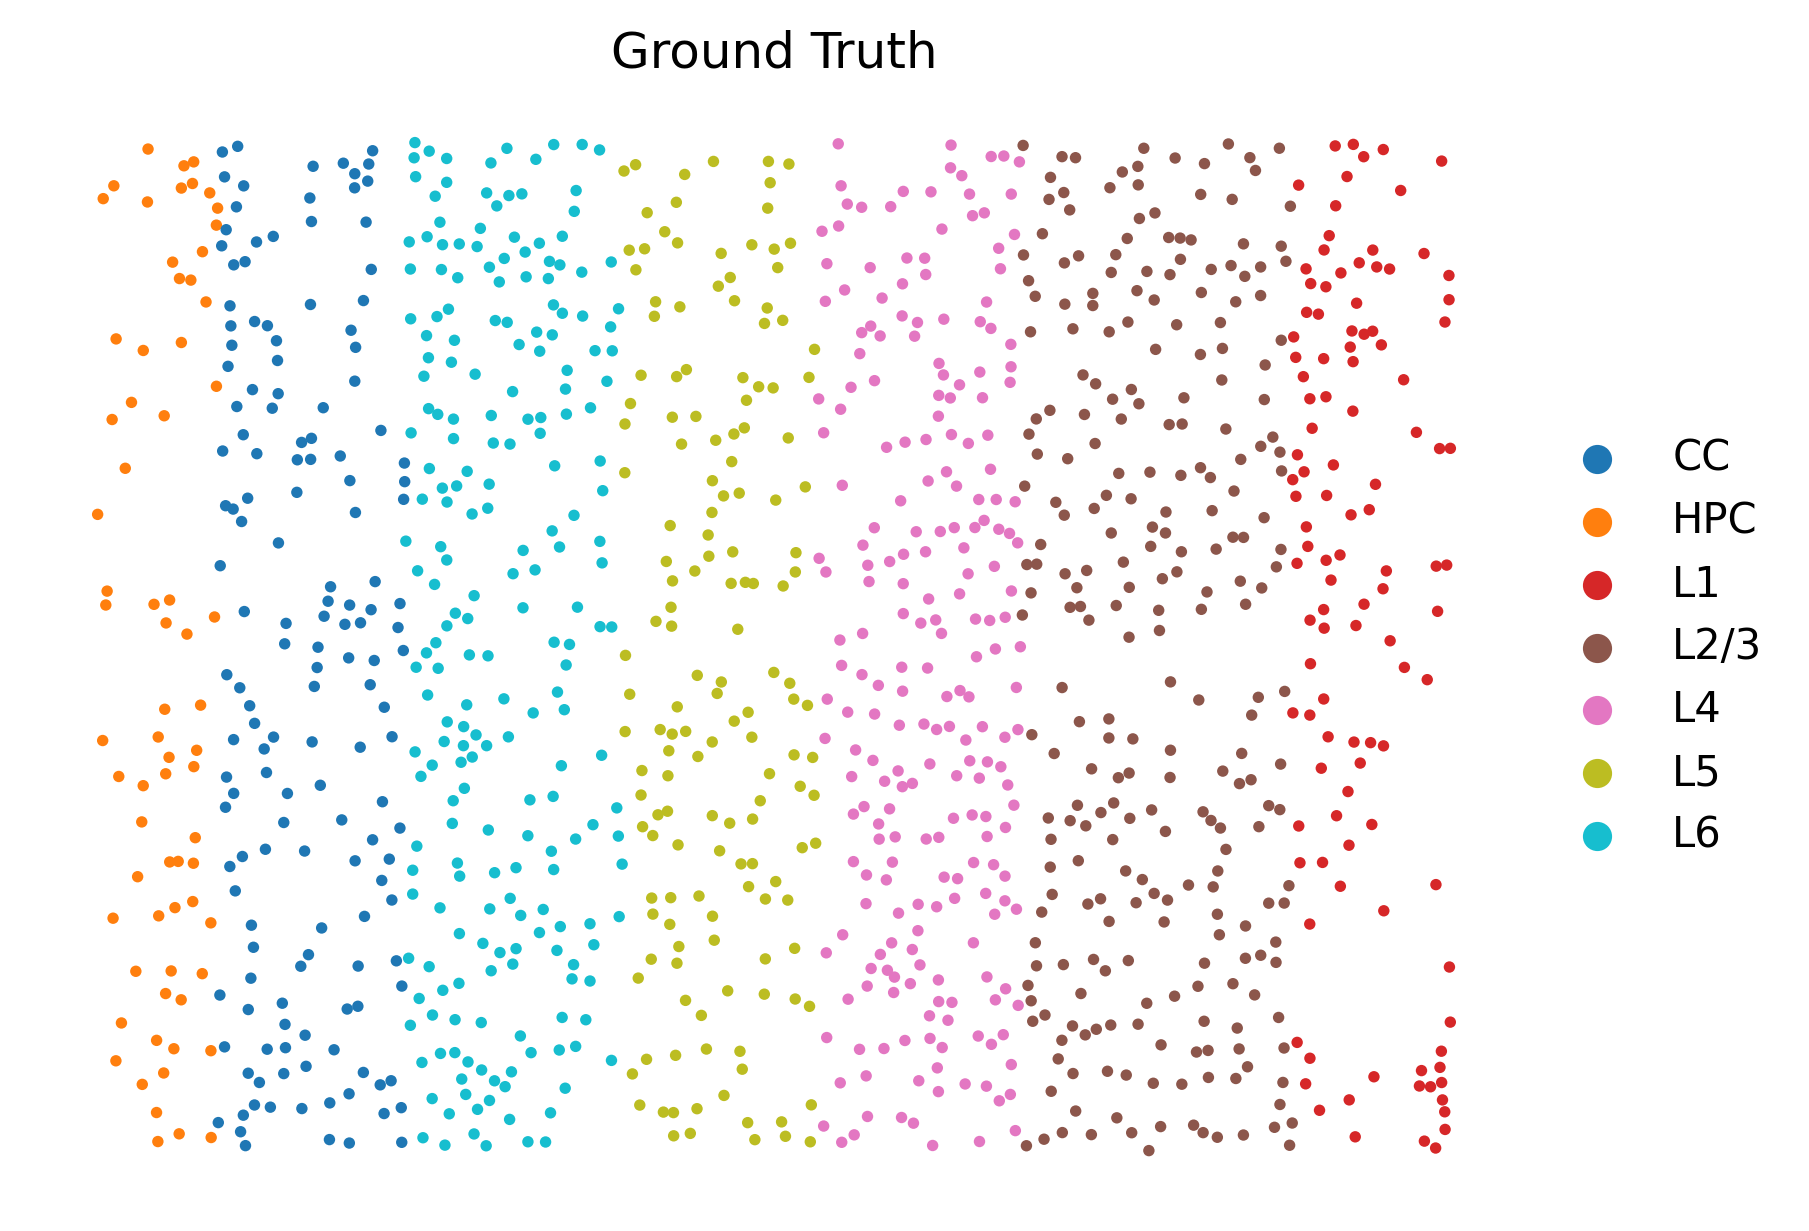

In [19]:

sc.pl.embedding(
    adata,
    basis="spatial",
    color="label",
    s=30,
    show=False,
    alpha=1.0,
    edgecolor="none",
    palette="tab10",
    frameon=False,
    title="Ground Truth"
)
plt.savefig(f"{figures_dir}/{sample_name}_label.png", bbox_inches='tight', pad_inches=0.1)
for ext in ['png', 'svg', 'pdf']:
    plt.savefig(f"{figures_dir}/{sample_name}_label.{ext}", bbox_inches='tight', dpi=300 if ext=='png' else None)
plt.show()
plt.close()